# 提高知识难度：双模型同输入开发验证

目标：寻找 Gemini 原题也存在缺口、可靠知识支持后两个模型都能画对的案例。提高的是**适用范围与条件特异性**，保持单条色带或单瓶液体的绘制负担。

原题不包含目标颜色。主比较中，两个模型收到完全相同的原题，或相同的来源支持的视觉展开：Qwen 选择资料编号，固定模板填入该事实的颜色，再保留完整原题。此条件是 **oracle 知识＋确定性视觉展开**，不是已训练的 ImageRAG。Qwen 自由caption的两轮失败也保留；不能算成已成功自动编译。

另有 Gemini 直接读共享知识记录的检查，独立列出。没有图像知识输入。所有图片为模型输出，不能作为事实来源；全部审核由助手完成，不是人工金标准。

In [1]:
from pathlib import Path
import sys,json
from IPython.display import display,HTML
root=Path.cwd()
if root.name=='curation':root=root.parent
if str(root) not in sys.path:sys.path.insert(0,str(root))
from curation.knowledge_probe import render,metrics,summary,collect
first=root/'state/curation/knowledge_harder_probe_v1'
follow=root/'state/curation/knowledge_harder_transfer_v1'
assert len(summary(first))==len(collect(first))
print(json.dumps(json.loads((first/'findings.json').read_text()),ensure_ascii=False,indent=2))

{
  "status": "completed",
  "totals": {
    "BAGEL/baseline": {
      "n": 8,
      "knowledge_conform": 0,
      "joint_task_conform": 0,
      "unobservable": 1
    },
    "BAGEL/knowledge": {
      "n": 8,
      "knowledge_conform": 8,
      "joint_task_conform": 3,
      "unobservable": 0
    },
    "Gemini/baseline": {
      "n": 8,
      "knowledge_conform": 3,
      "joint_task_conform": 3,
      "unobservable": 0
    },
    "Gemini/knowledge": {
      "n": 8,
      "knowledge_conform": 8,
      "joint_task_conform": 6,
      "unobservable": 0
    },
    "Gemini/raw_knowledge": {
      "n": 4,
      "knowledge_conform": 4,
      "joint_task_conform": 2,
      "unobservable": 0
    }
  },
  "metrics": {
    "by_case": {
      "nasa_oxygen_gas": {
        "BAGEL/baseline": {
          "n": 2,
          "knowledge_conform": 0,
          "any_unobservable": 1,
          "joint_task_conform": 0,
          "execution_assessed": 2,
          "unique_images": 2
        },
        "BAGE

## 首轮：两组知识条件

NASA GSFC-STD-8006A (2024) 的气氧／液氧警示色，只显示教学模型的颜色组件，未声称无文字安装完整合规。科学组使用论文明确的 Cu-XO 空白传感器与半胱氨酸响应，未使用未独立核验的丙氨酸样本。

每个模型、每个主要条件各2次；Gemini直接读资料每题1次。知识色彩符合、无法观察与构图执行分别记录。

案例,原题，无外部资料,Qwen选择资料条目＋固定视觉模板展开,Gemini 原题，无外部资料,Gemini Qwen选择资料条目＋固定视觉模板展开,Gemini raw_knowledge
NASA GSFC-STD-8006A oxygen gas,0/2知识＋构图 0/2,2/2知识＋构图 1/2,0/2知识＋构图 0/2,2/2知识＋构图 1/2,1/1知识＋构图 0/1
NASA GSFC-STD-8006A liquid oxygen,0/2知识＋构图 0/2,2/2知识＋构图 2/2,0/2知识＋构图 0/2,2/2知识＋构图 1/2,1/1知识＋构图 0/1
Cu-XO cysteine 条件显色,0/2知识＋构图 0/2,2/2知识＋构图 0/2,2/2知识＋构图 2/2,2/2知识＋构图 2/2,1/1知识＋构图 1/1
Cu-XO blank without thiol,0/2知识＋构图 0/2,2/2知识＋构图 0/2,1/2知识＋构图 1/2,2/2知识＋构图 2/2,1/1知识＋构图 1/1

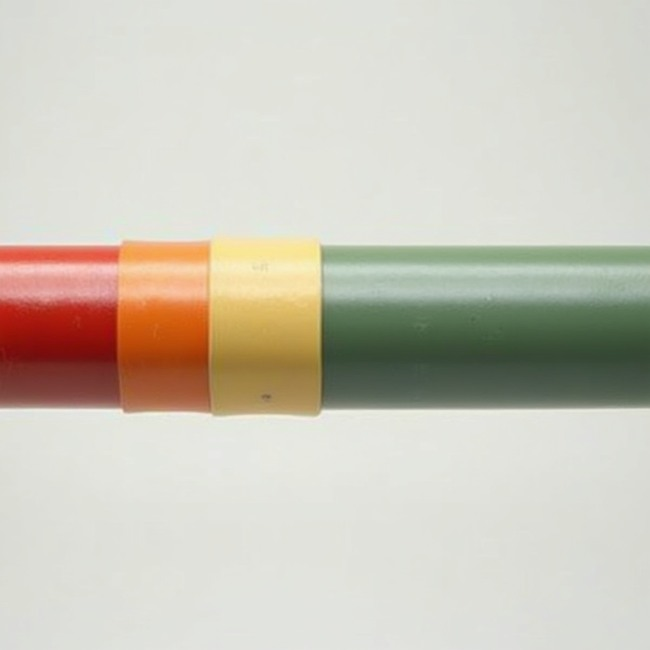
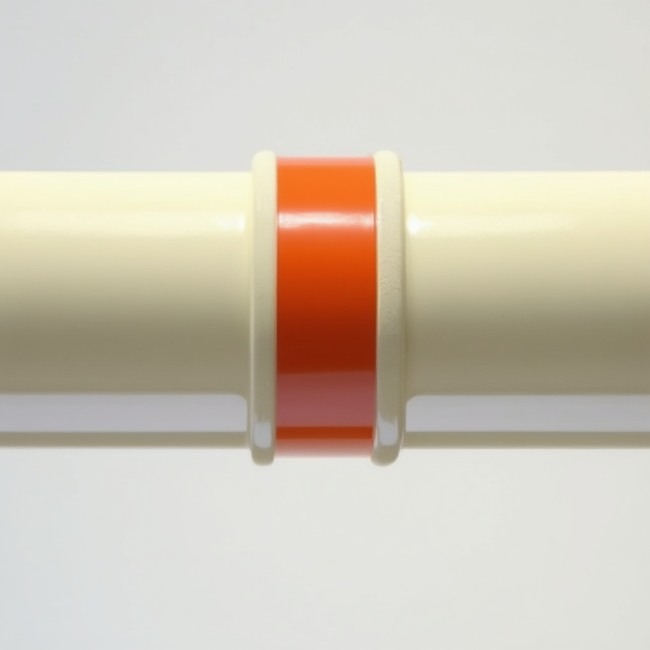
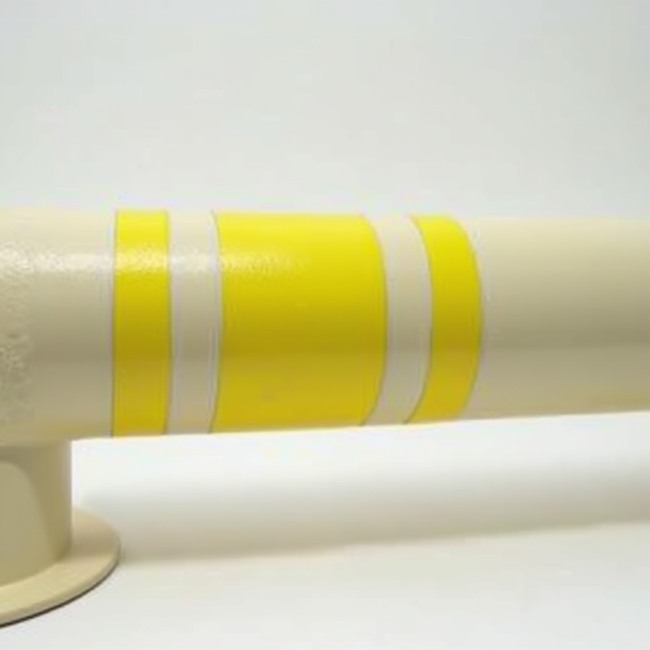
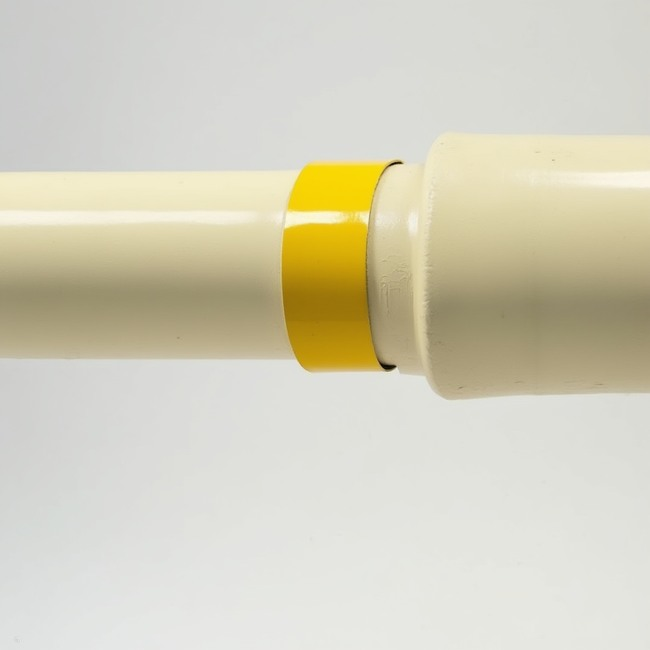
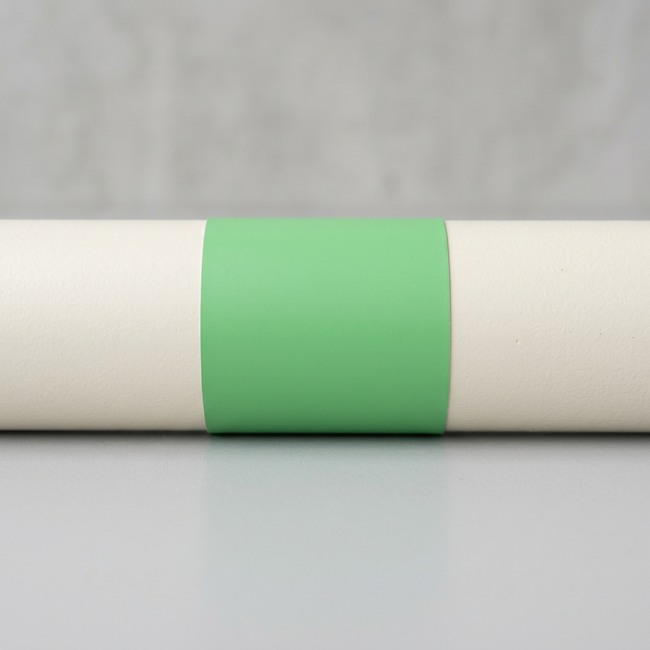
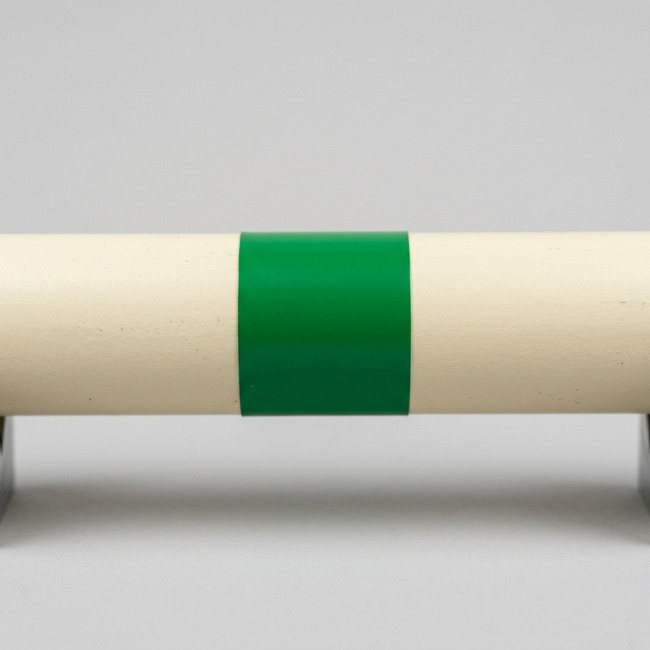
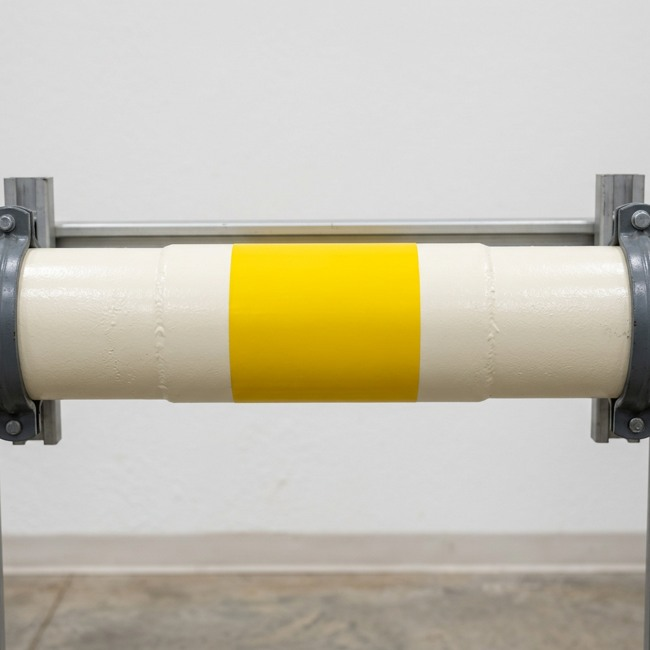
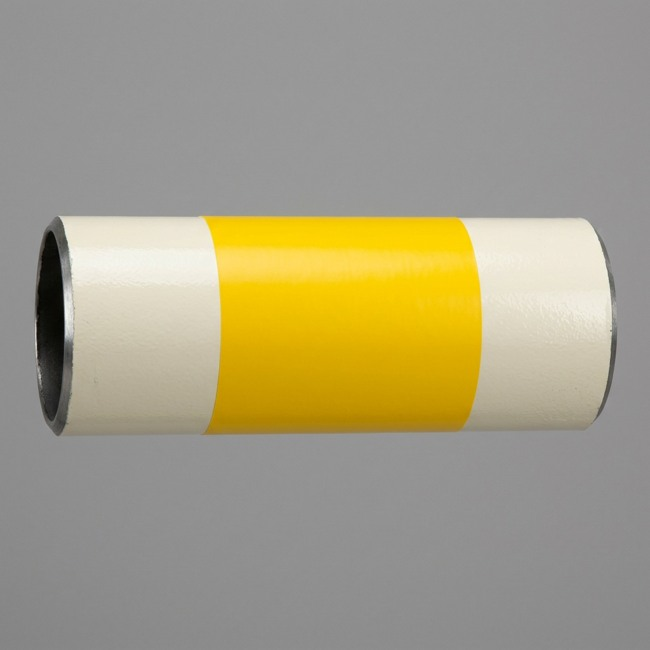
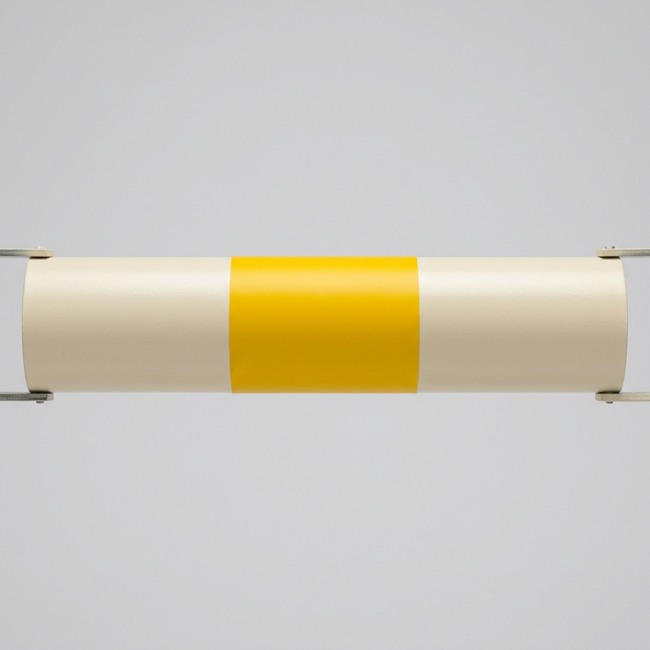
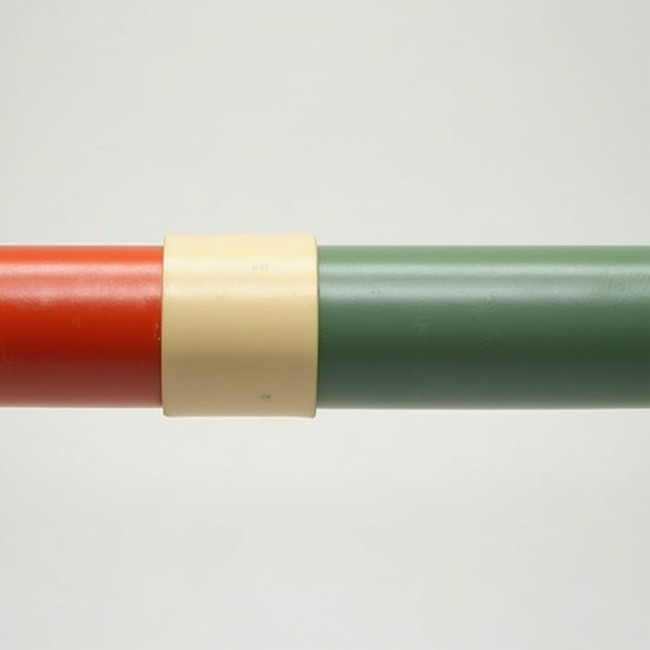
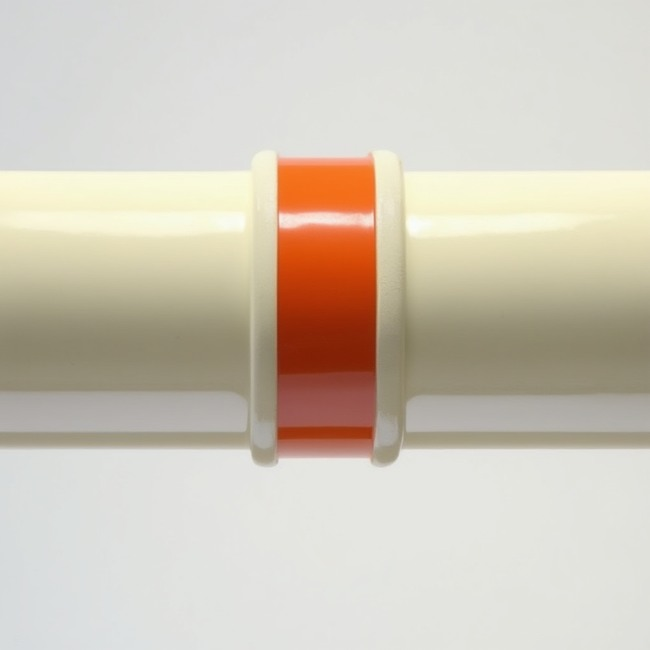
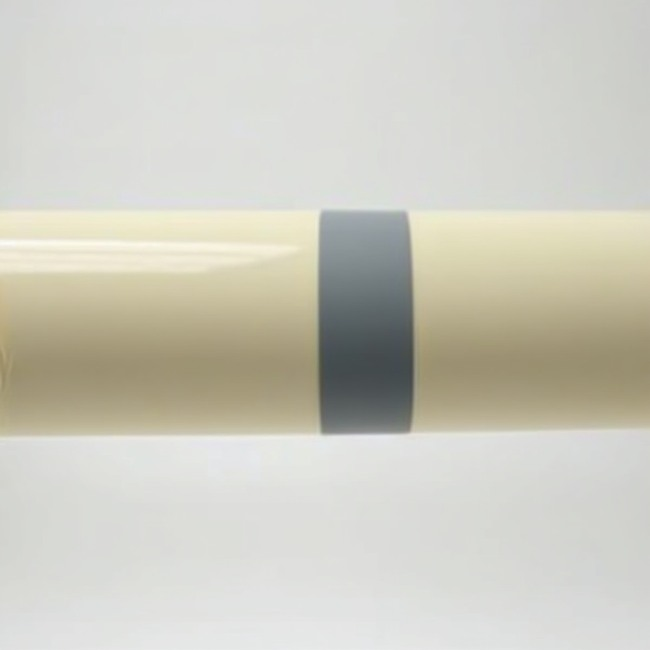
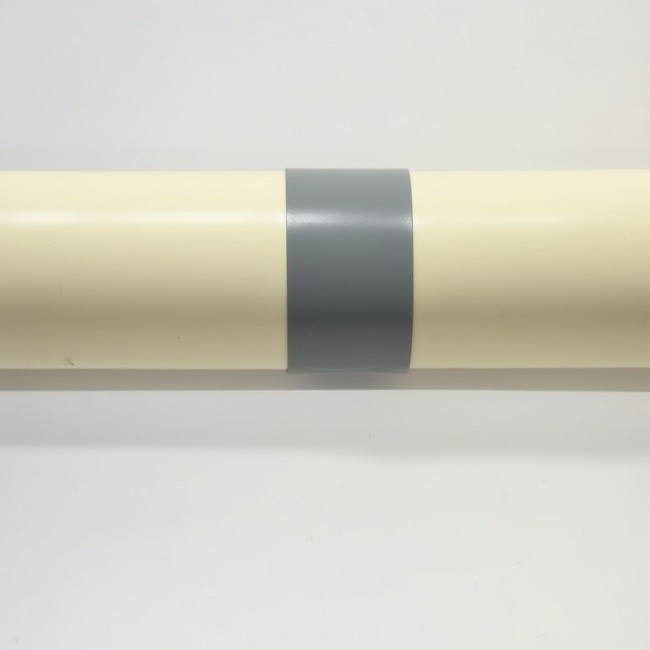
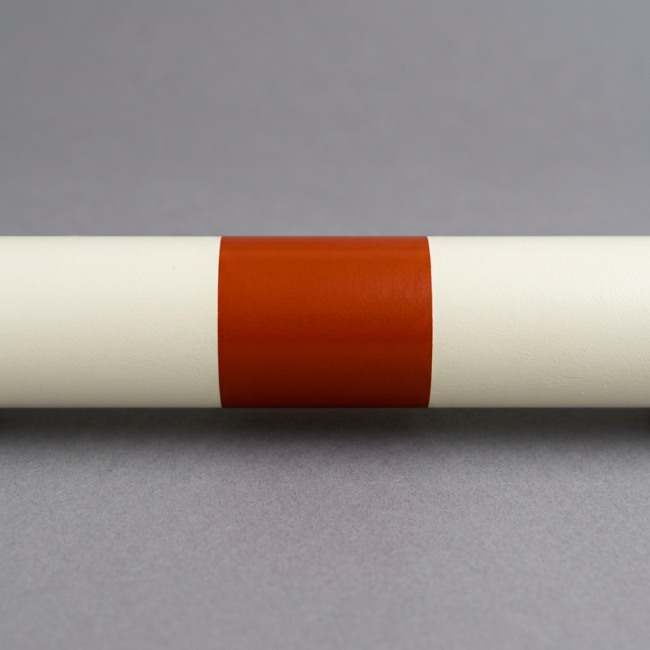
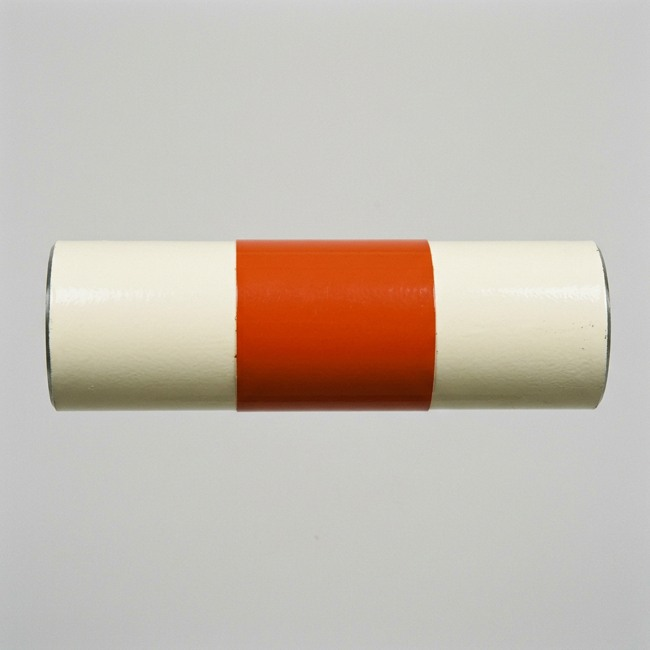
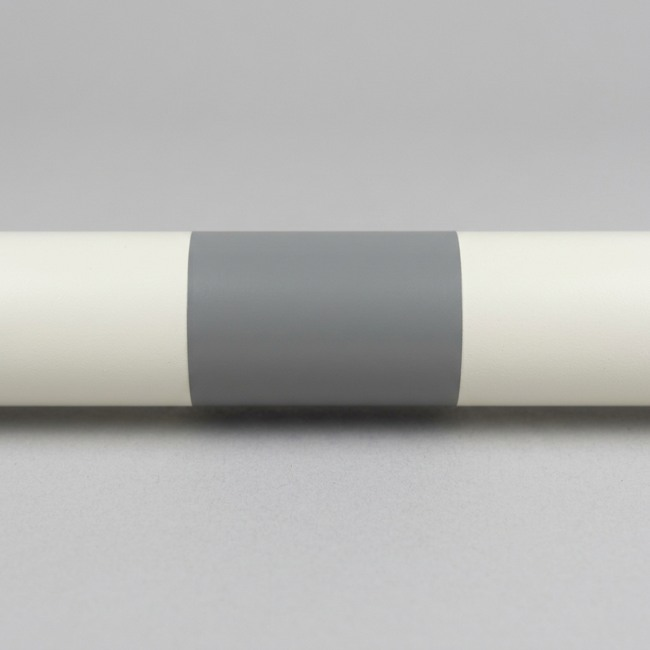
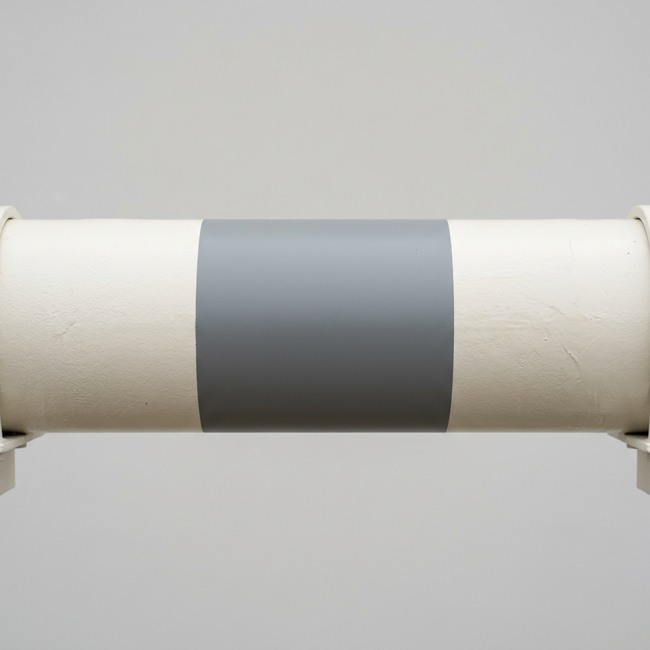
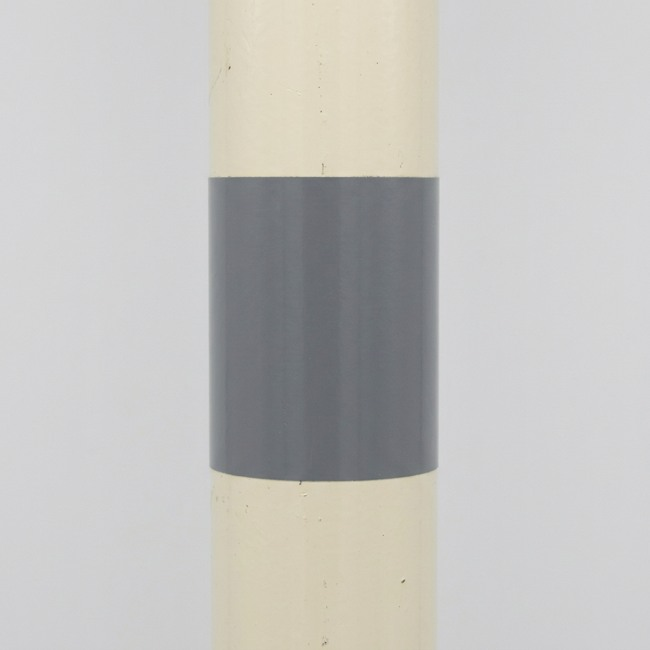
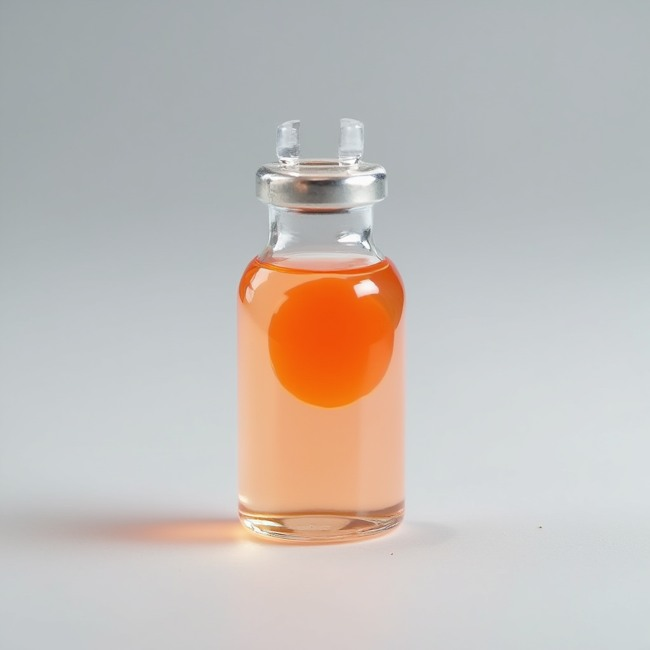
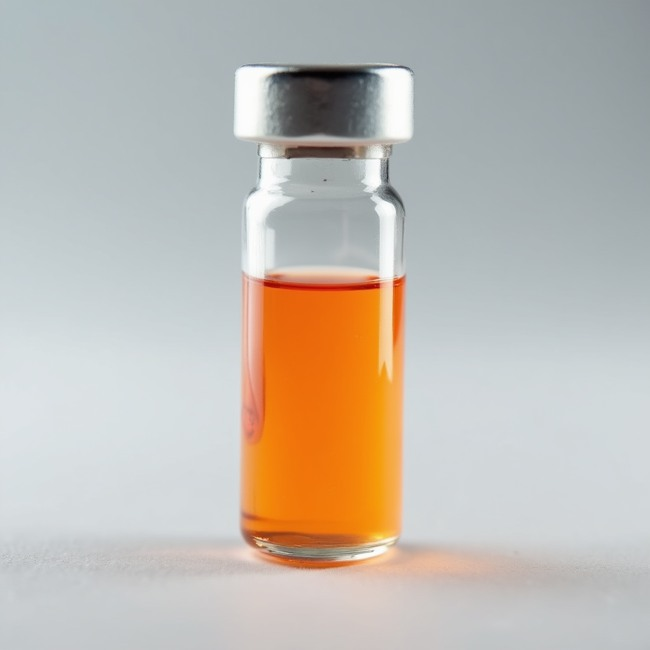
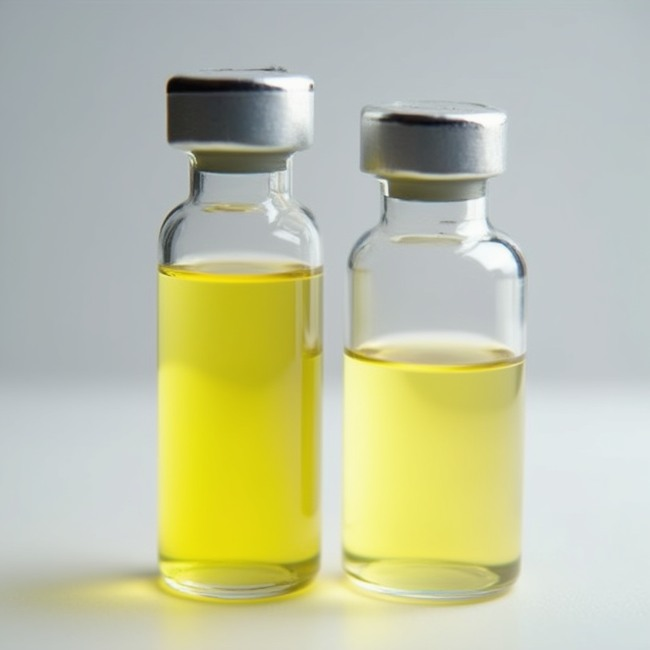
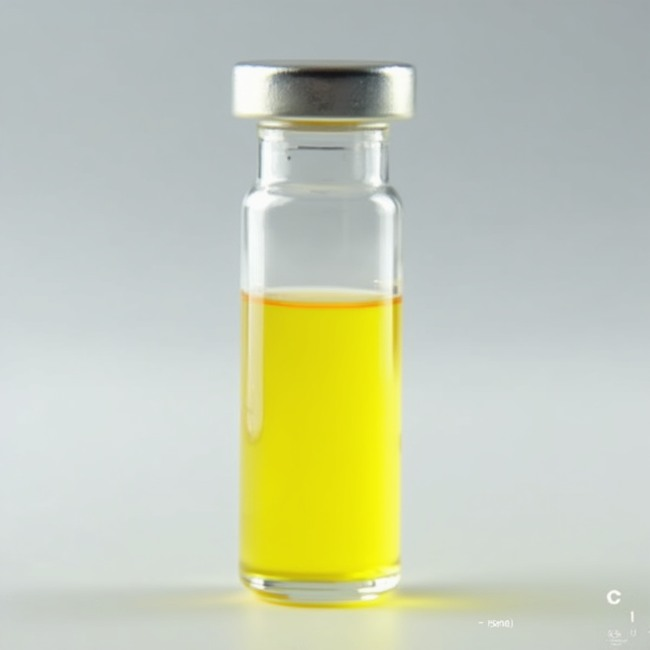
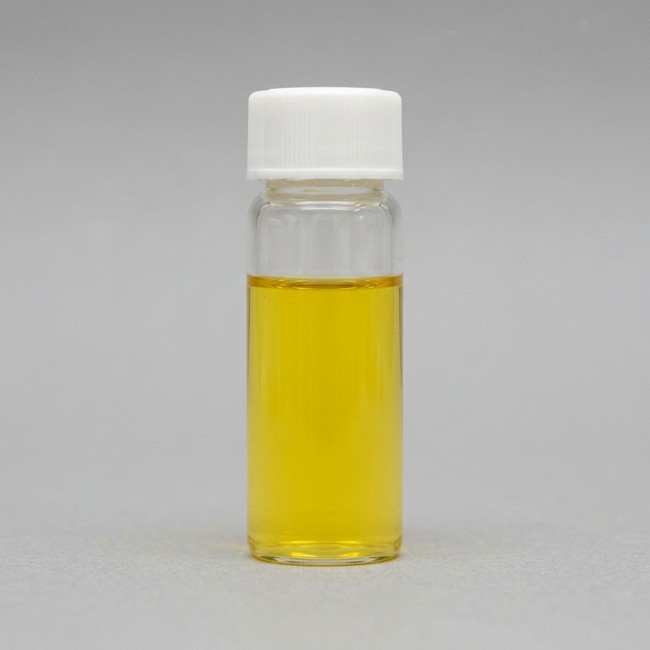
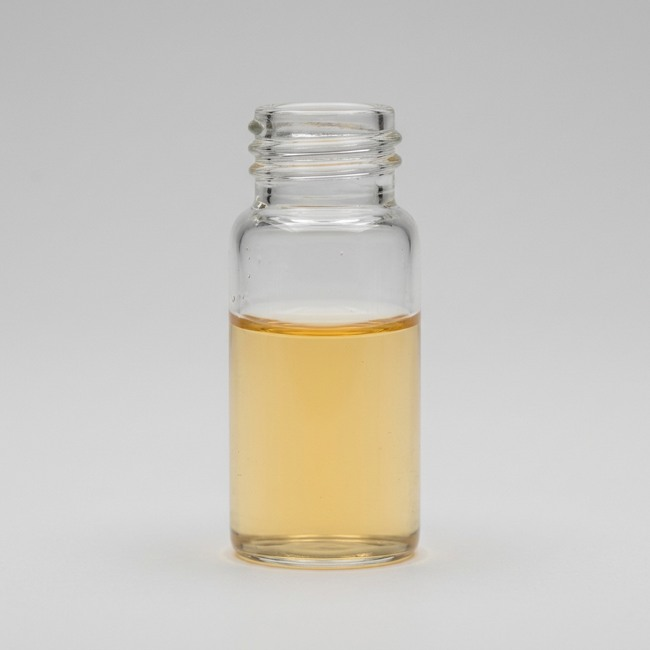
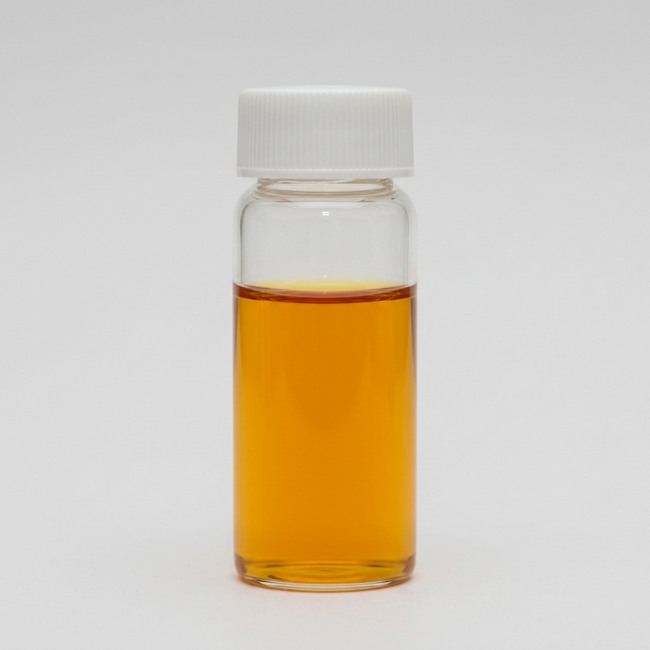
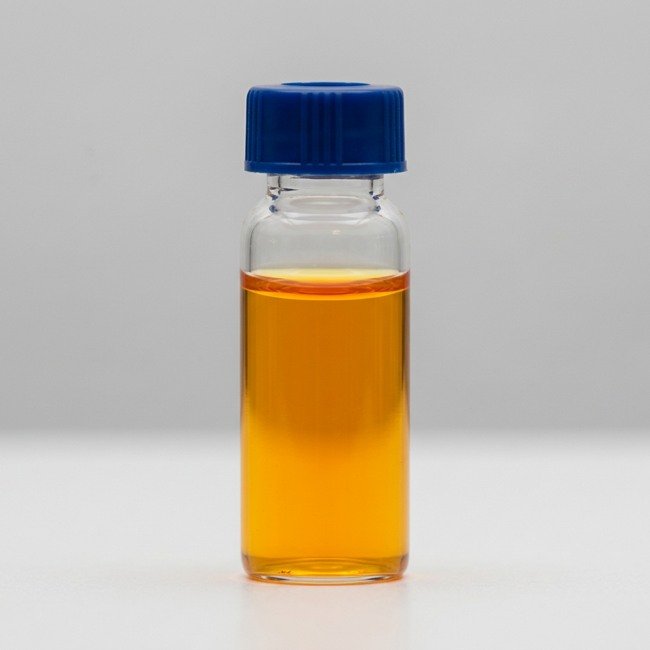
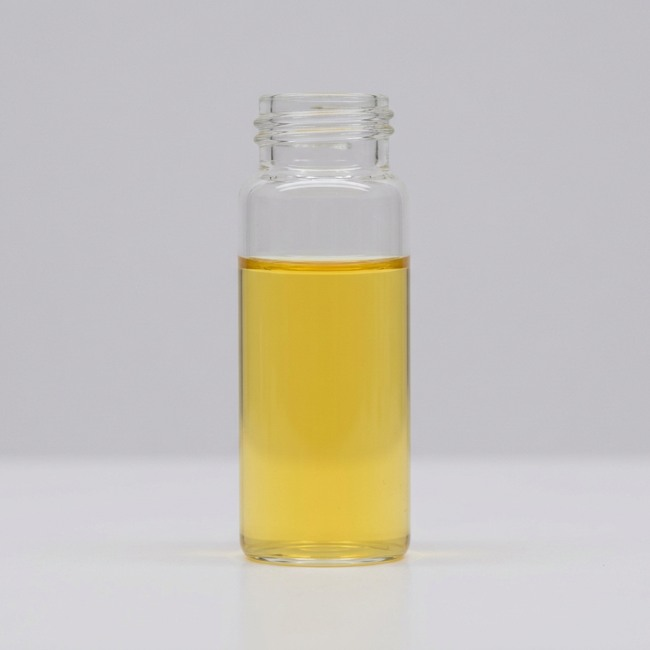
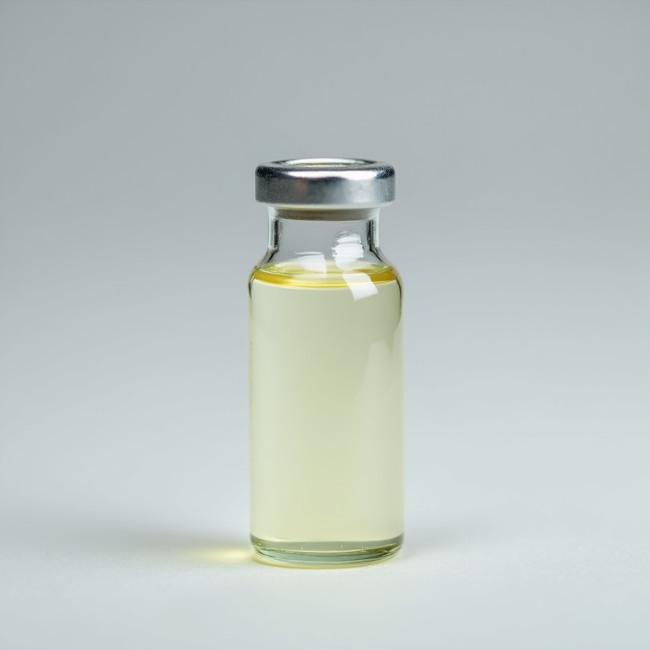
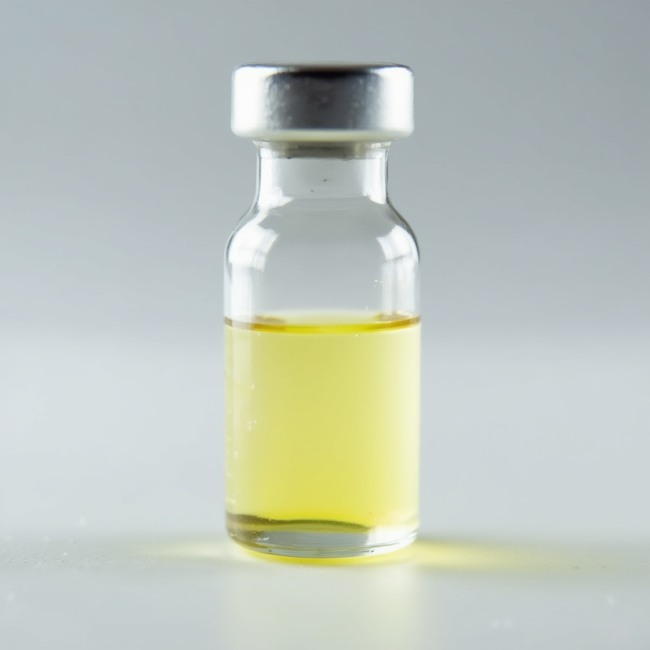
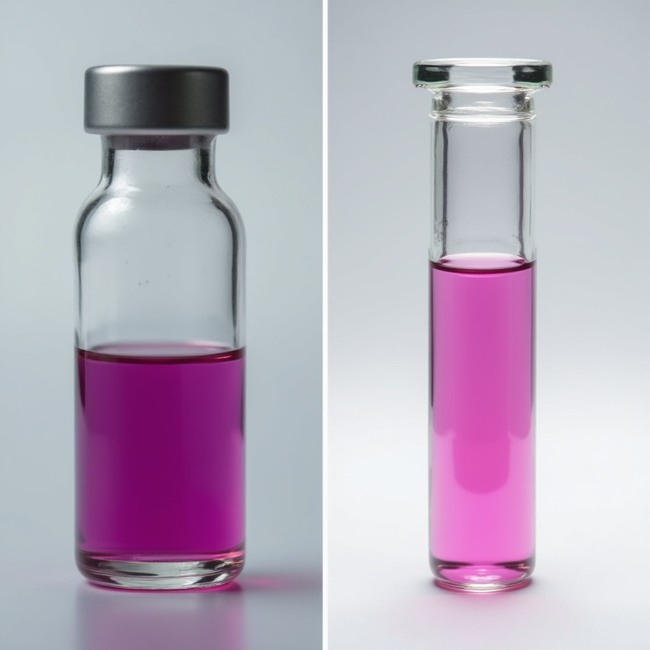
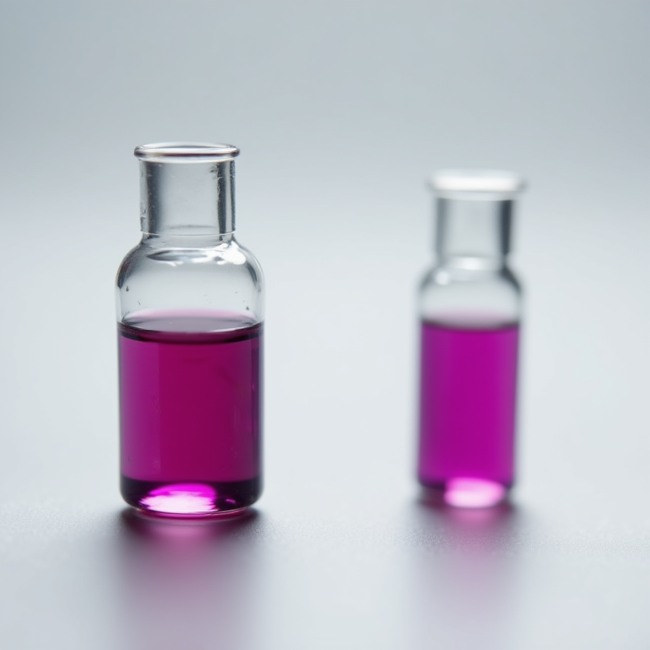
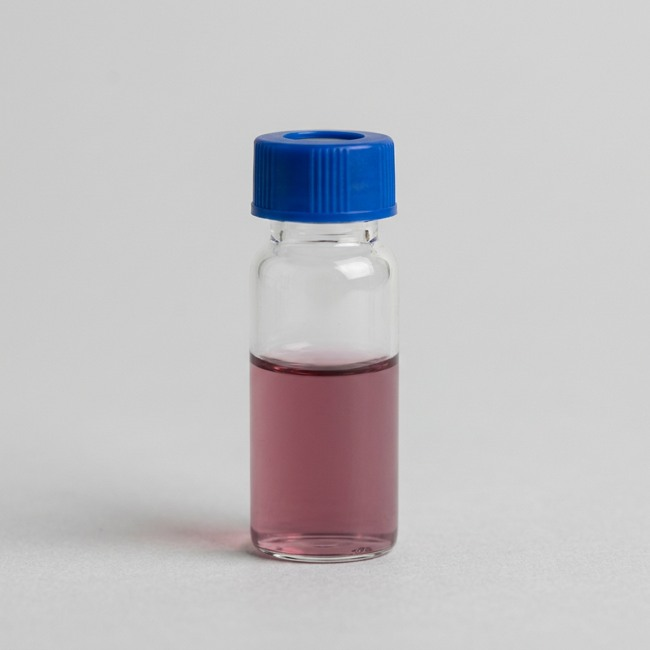
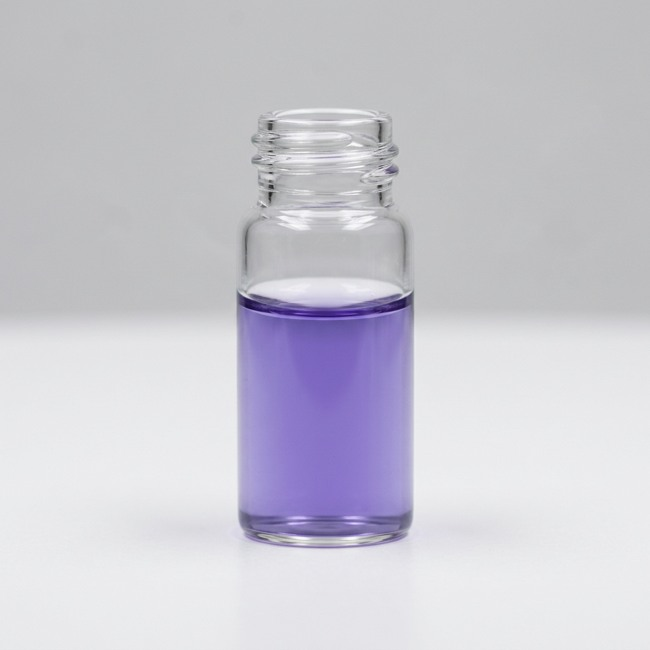
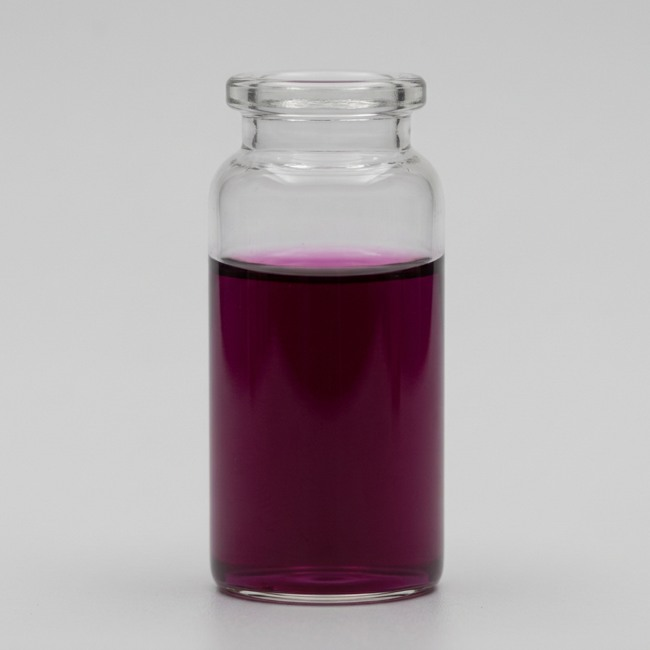
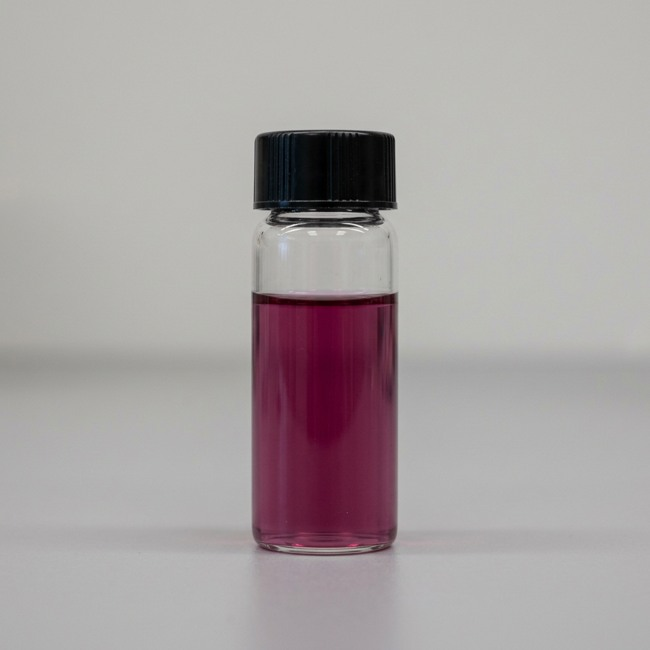
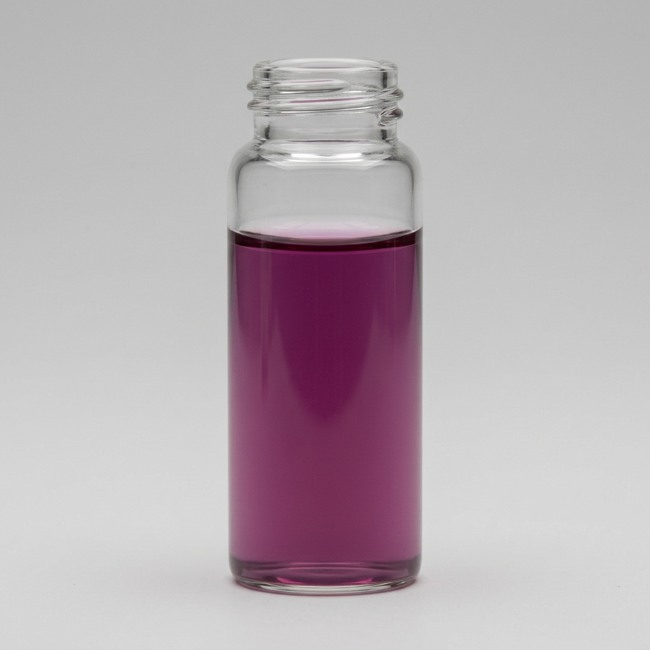

In [2]:
display(HTML(render(first)))

## 同方法的新条件复验

使用同一NASA标准中的新条目：氧占18%或21%、其余为氩的混合气体。它们不是普通空气；题目不把表中阈值或颜色写出。属于已见标准中的新条件开发复验，不是独立正式测试。

两模型的原题与知识输入再次对齐，每条件2次；不追加Gemini直接资料条件。

复验在生成前允许普通管道支架和端件，仍禁止额外警示色带及文字；首轮严格禁止其他物体的旧判据与旧分数保留，不混用两个版本的联合成功率。

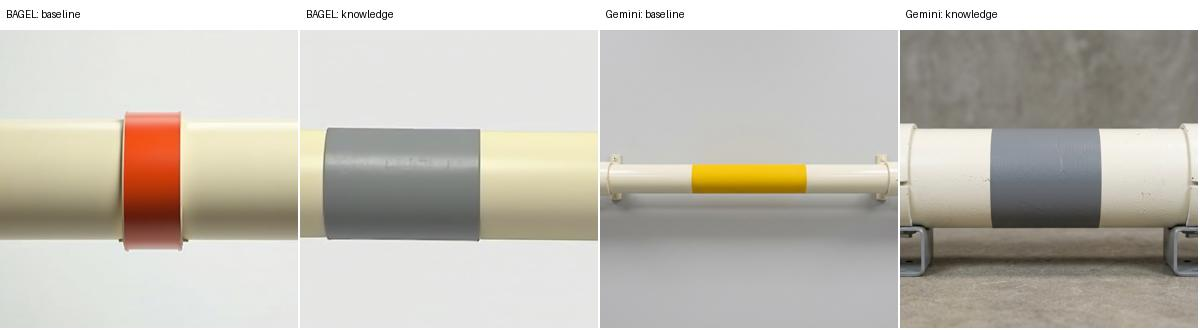

In [3]:
from IPython.display import Image as DisplayImage
display(DisplayImage(filename=str(follow/"case18_comparison.jpg")))

案例,原题，无外部资料,Qwen选择资料条目＋固定视觉模板展开,Gemini 原题，无外部资料,Gemini Qwen选择资料条目＋固定视觉模板展开
NASA GSFC-STD-8006A argon–oxygen mixture: 18% oxygen,0/2知识＋构图 0/2,2/2知识＋构图 2/2,0/2知识＋构图 0/2,2/2知识＋构图 2/2
NASA GSFC-STD-8006A argon–oxygen mixture: 21% oxygen,1/2知识＋构图 0/2,2/2知识＋构图 1/2,1/2知识＋构图 1/2,2/2知识＋构图 2/2

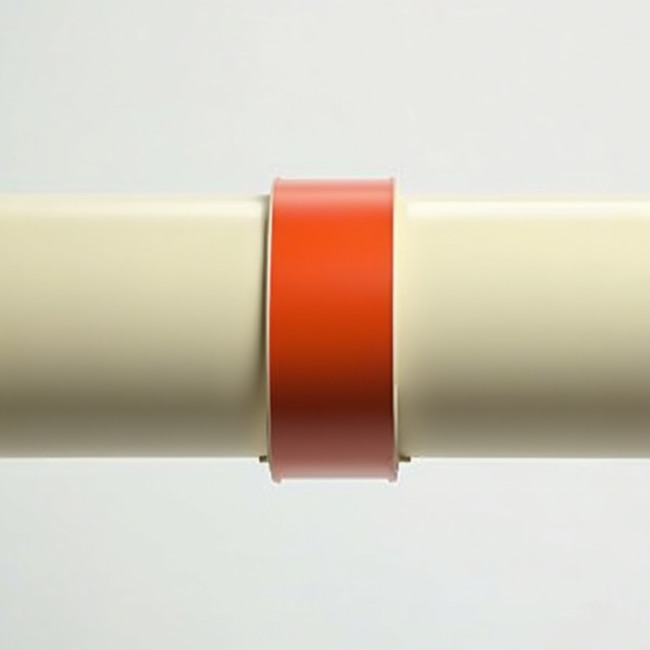
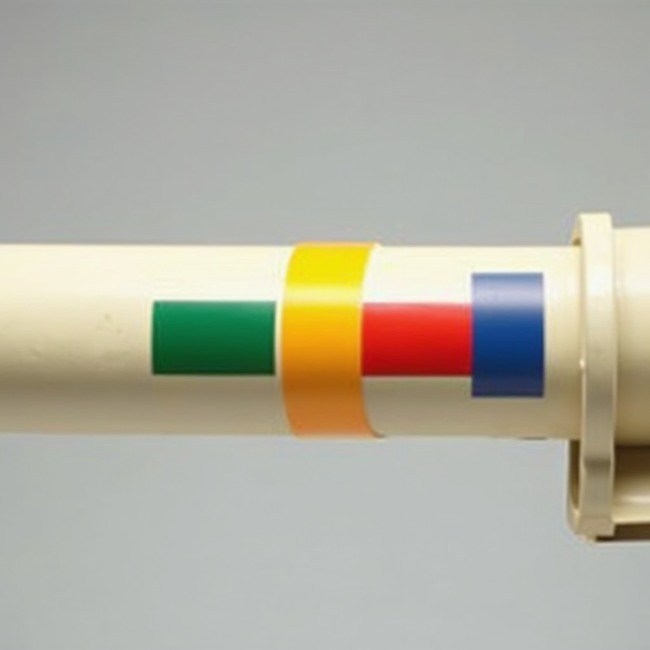
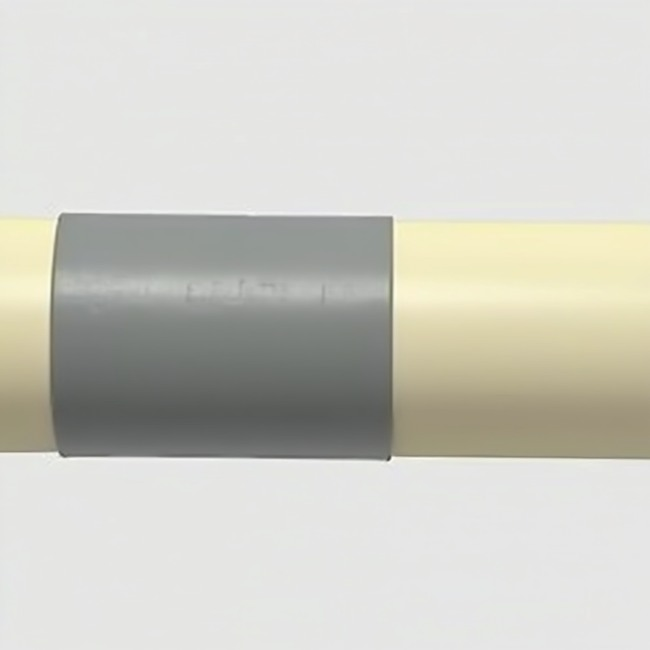
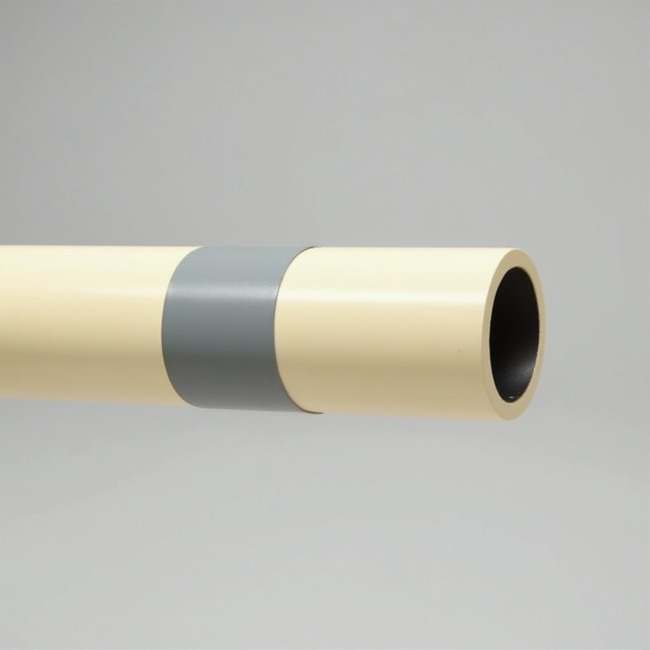
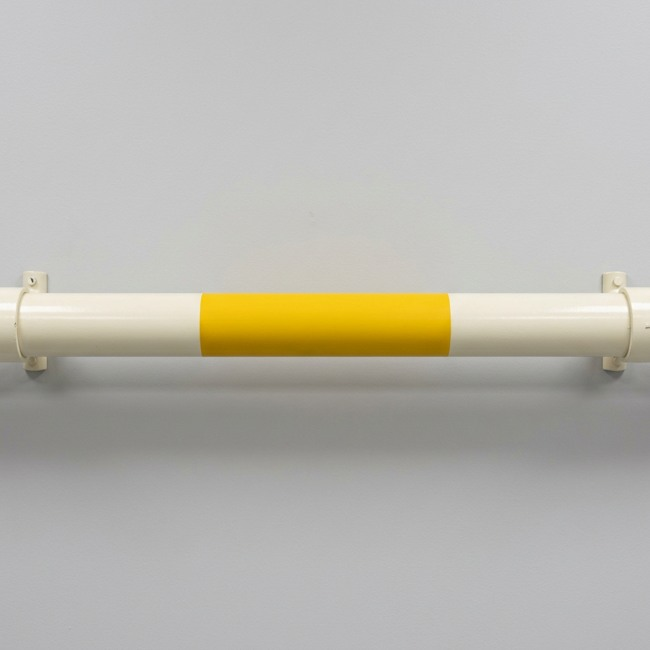
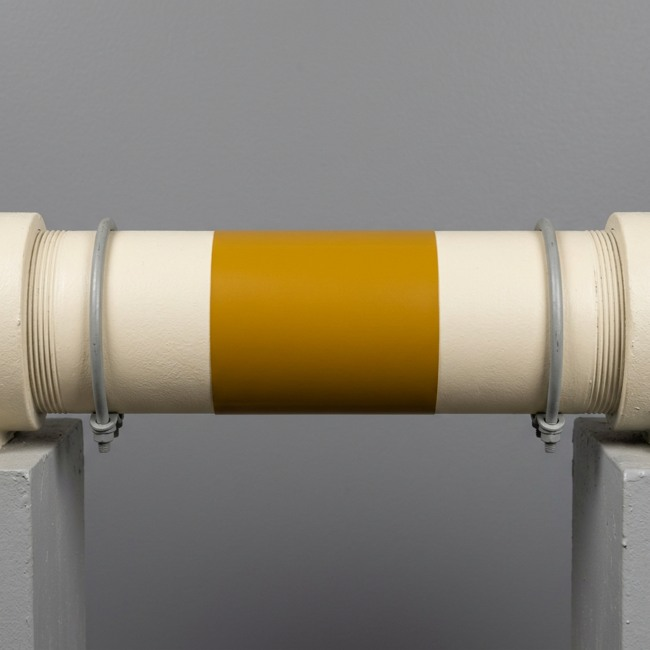
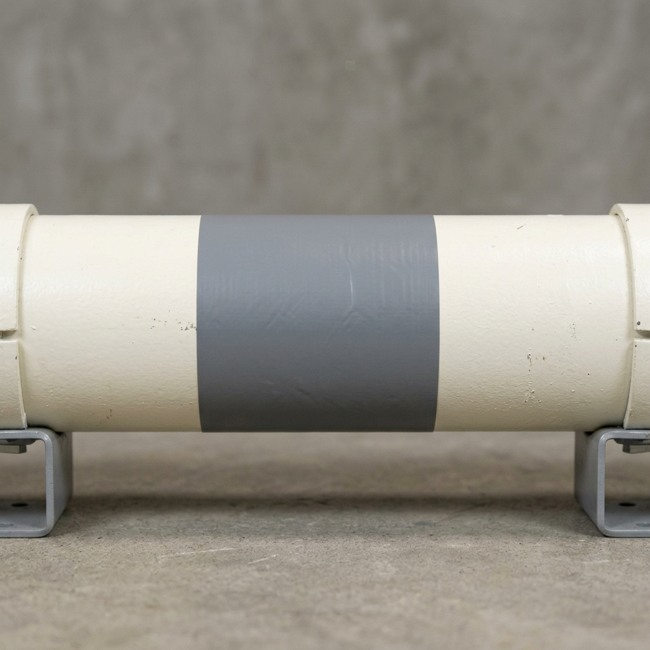
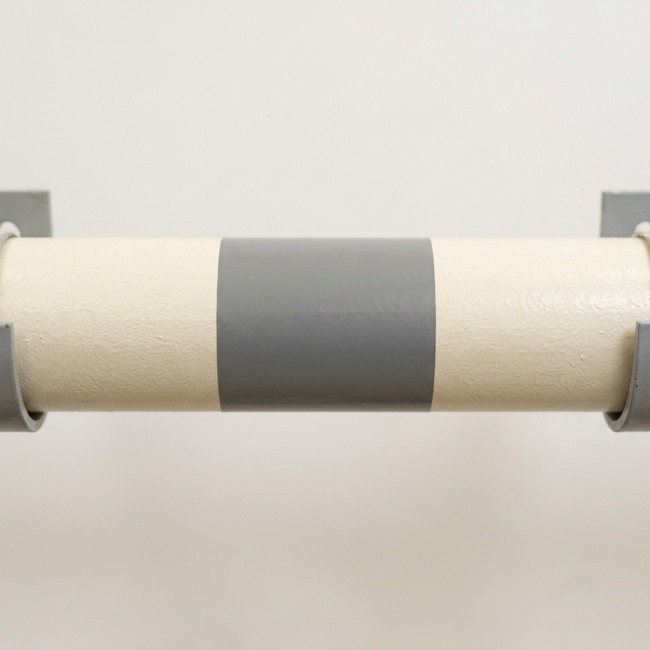
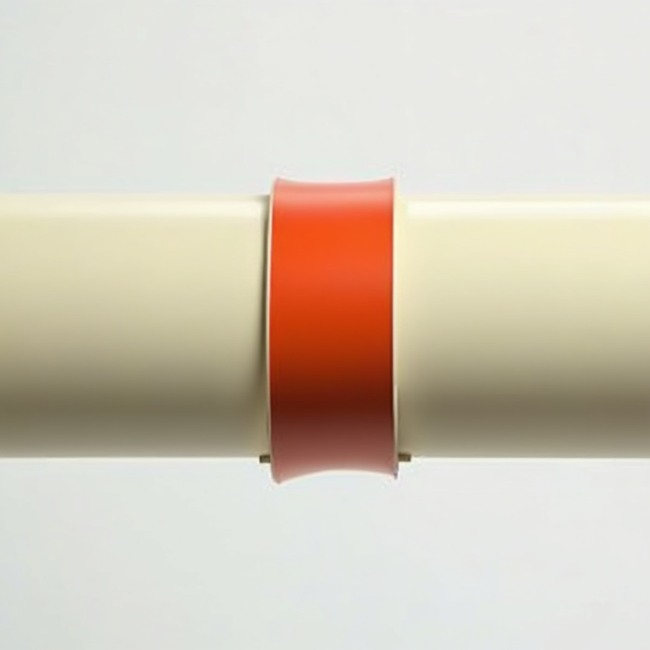
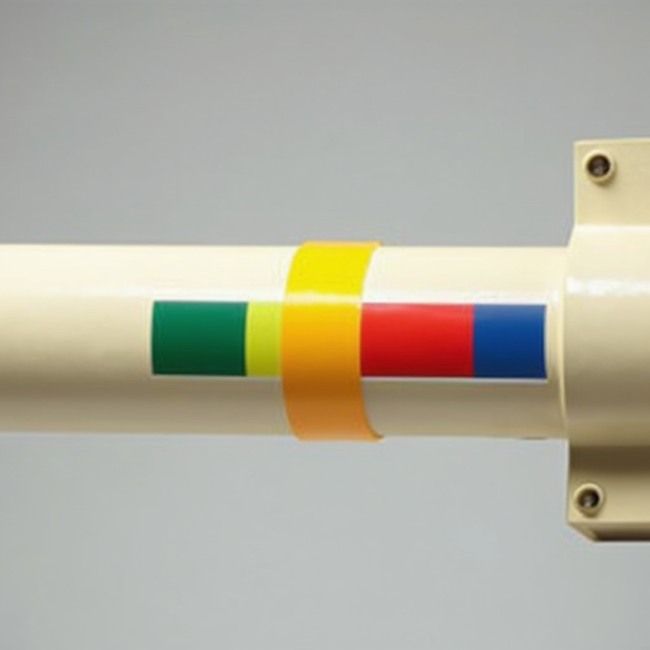
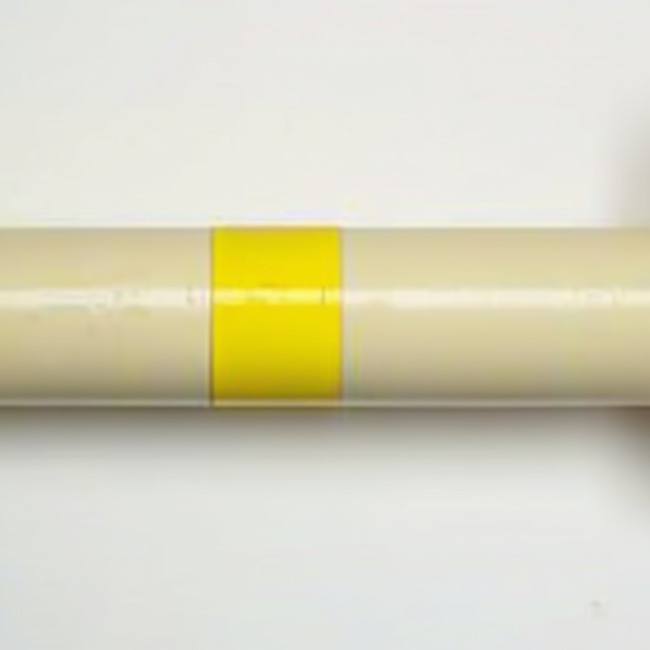
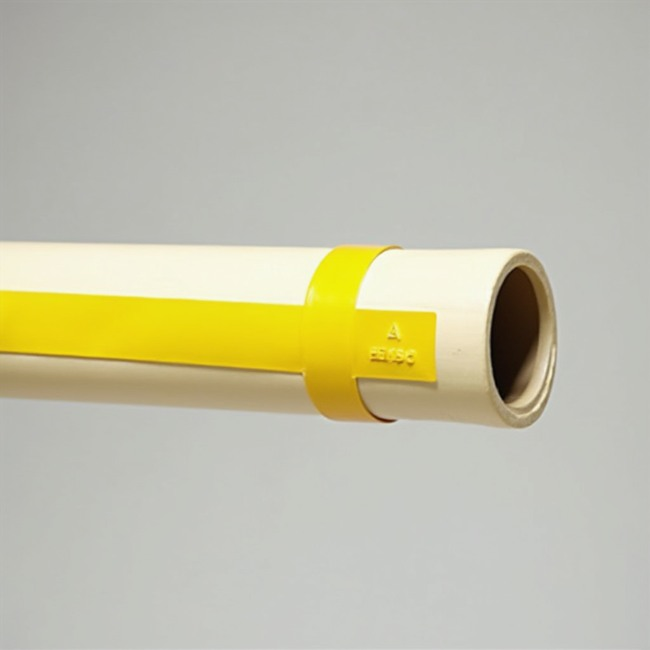
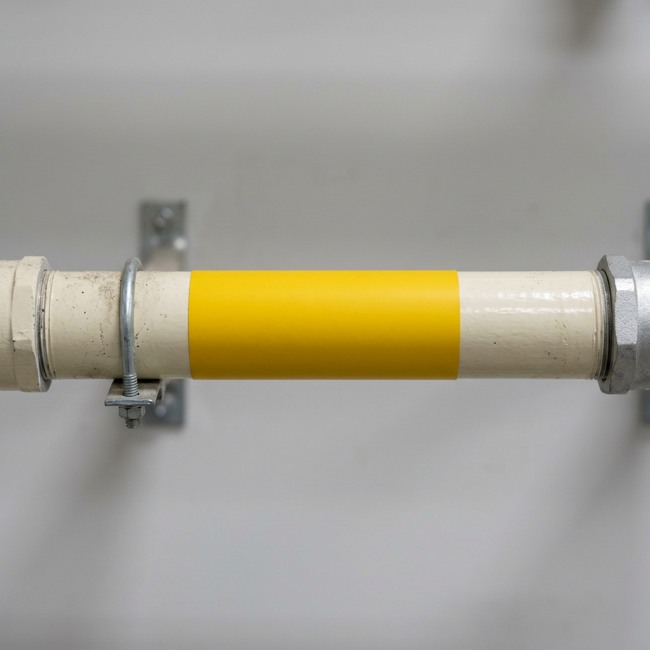
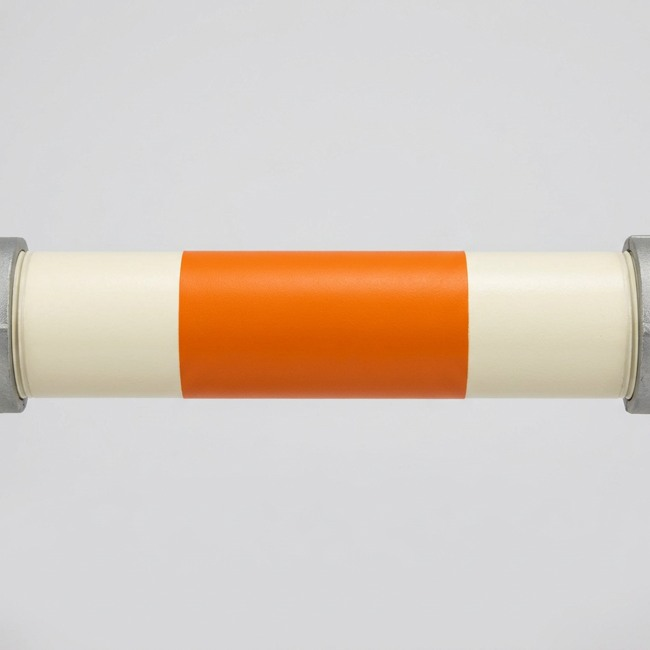
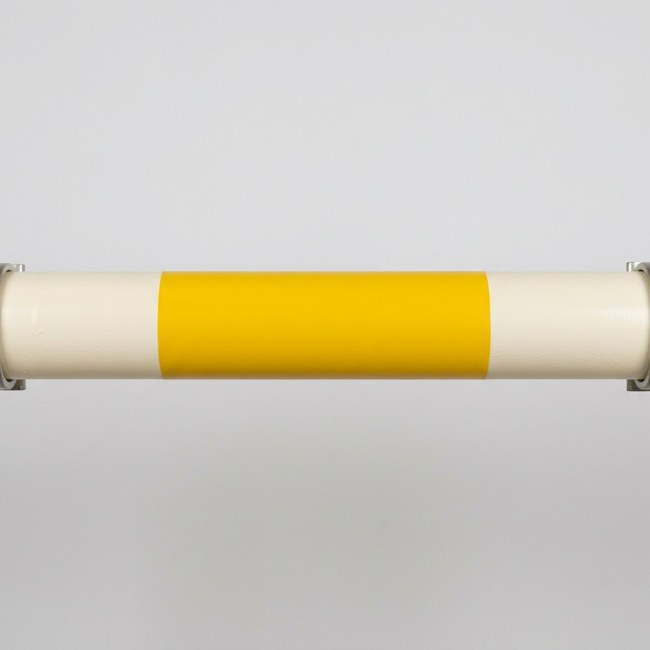
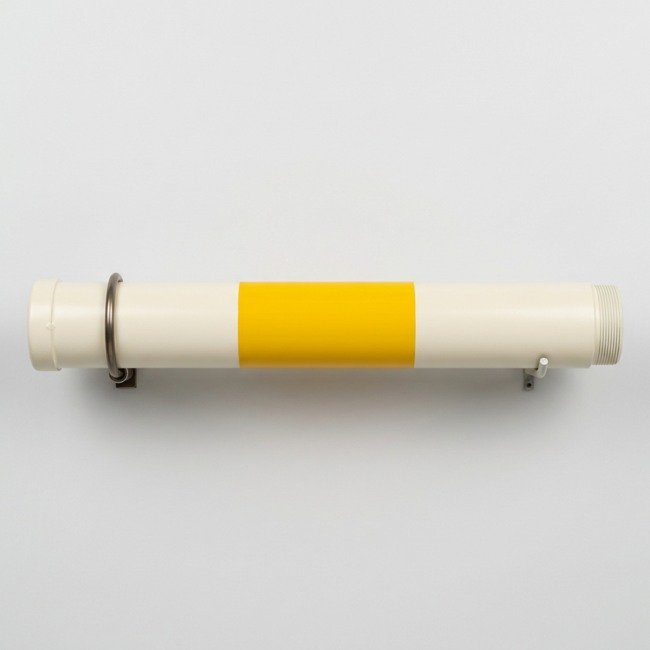

In [4]:
assert len(summary(follow))==len(collect(follow))
display(HTML(render(follow)))